# Single-Cell Transcriptomic Analysis of a Colorectal Cancer Tumor

**Phase A of the Geneformer-Finetune project**

Author: Aruna Kumar.
Dataset: Pelka et al. 2021, *Cell* — "Spatially organized multicellular immune hubs in human colorectal cancer."
Patient analyzed: **C103** (45-year-old male, left-sided MMRp colon adenocarcinoma, stage T1-3 N-, low grade)

---

## Executive Summary

This notebook presents an end-to-end single-cell RNA-seq analysis of one colorectal cancer (CRC) tumor sample, working through the standard scverse/Scanpy pipeline: quality control → doublet removal → normalization → dimensionality reduction → clustering → cell-type annotation → tumor identification → immune subtype refinement → publication-quality figures.

### Key findings

| Finding | Evidence |
|---|---|
| **Tumor-dominated sample** | 55% of 6,042 cells are epithelial across 5 sub-clusters; 44% in S/G2M cell-cycle phase (vs <10% in normal tissue) |
| **Cold immune microenvironment** | 26% of immune cells are FOXP3+ Tregs; macrophages 2.8× M2-polarized over M1; dominant T-cell pool is naive |
| **Cytotoxic compartment is small and exhausted** | 3.4% of cells are cytotoxic-T; they co-express PD-1/TIM-3/LAG3 markers of exhaustion |
| **Consistent with MMRp/left-sided clinical features** | All findings predict poor response to checkpoint immunotherapy |

### Deliverable

`data/processed/09_crc_donor_final_annotated.h5ad` — 6,042 cells × 38,361 genes with 67 annotation columns covering QC, doublet status, three Leiden clusterings, manual + CellTypist labels, cell-cycle phase, and immune subtype scores. Ready for downstream spatial transcriptomics (Phase B) and Geneformer fine-tuning (Phase C).

### Methods summary

| Step | Tool | Outcome |
|---|---|---|
| Data acquisition | `cellxgene_census.download_source_h5ad` | 370,115-cell dataset |
| Donor selection | pandas filter on `donor_id` + `disease` | Patient C103, 6,096 cells |
| Quality control | `sc.pp.calculate_qc_metrics` + tumor-specific thresholds | 0 cells excluded (sample pre-cleaned) |
| Doublet detection | `sc.pp.scrublet` | 54 doublets removed (0.89%) |
| Normalization | `sc.pp.normalize_total` (CP10K) + `sc.pp.log1p` | 6,042 cells × 38,361 genes |
| Feature selection | `sc.pp.highly_variable_genes` (Seurat v3, 2,000 HVGs) | Top markers are lineage genes |
| Dim reduction | `sc.pp.pca` (50 components, 30 used) → `sc.pp.neighbors` (15 NN) → `sc.tl.umap` | Clean 2D embedding |
| Clustering | `sc.tl.leiden` at resolutions 0.4 / 0.8 / 1.5 | 11 / 13 / 20 clusters; selected 0.8 |
| Cell-type annotation | Manual markers + `CellTypist` (Immune_All_Low model) | Clean 1-to-1 mapping |
| Tumor identification | `sc.tl.score_genes_cell_cycle` (Tirosh 2016 lists) | 44.4% cycling fraction |
| Immune subtyping | `sc.tl.score_genes` on T-cell + M1/M2 signatures | Cold-tumor profile identified |

---


## 0. Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad
import cellxgene_census
import celltypist

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

sc.settings.set_figure_params(dpi=100, dpi_save=200, fontsize=10, frameon=False)
plt.rcParams["figure.facecolor"] = "white"

# Project paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES        = PROJECT_ROOT / "figures"
for p in (DATA_RAW, DATA_PROCESSED, FIGURES):
    p.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = FIGURES

print(f"Python {sys.version.split()[0]}  |  scanpy {sc.__version__}  |  anndata {ad.__version__}")

Python 3.10.10  |  scanpy 1.10.3  |  anndata 0.10.9


---

## 1. Data acquisition

We pull the Pelka et al. 2021 colon adenocarcinoma scRNA-seq dataset from cellxgene-census and subset to one tumor donor.

**Important data-handling note.** Cellxgene-curated datasets store the *original raw UMI counts* in `adata.raw.X` and place a *normalized* expression matrix in `adata.X`. To run a correct pipeline (which expects raw counts at the start), we replace `adata.X` with `adata.raw.X` immediately after loading.


In [2]:
# Discover the dataset.
census = cellxgene_census.open_soma(census_version="latest")
datasets = census["census_info"]["datasets"].read().concat().to_pandas()
crc = (
    datasets[datasets["collection_name"].str.contains("colorectal|colon", case=False, na=False)]
    .sort_values("dataset_total_cell_count", ascending=False)
    .reset_index(drop=True)
)
chosen_dataset_id = crc.iloc[0]["dataset_id"]
print(f"Selected dataset: {crc.iloc[0]['dataset_title']}")
print(f"Total cells in source: {crc.iloc[0]['dataset_total_cell_count']:,}")
census.close()

Selected dataset: All Cells
Total cells in source: 370,115


In [3]:
# Download the .h5ad if not present.
local_h5ad = DATA_RAW / f"crc_{chosen_dataset_id}.h5ad"
if not local_h5ad.exists():
    print("Downloading source .h5ad (~3.5 GB) ...")
    cellxgene_census.download_source_h5ad(
        dataset_id=chosen_dataset_id,
        to_path=str(local_h5ad),
        census_version="latest",
    )
print(f"File: {local_h5ad}  ({local_h5ad.stat().st_size / 1e9:.2f} GB)")

File: /Users/arunak/Claude/Geneformer-finetune/data/raw/crc_16023185-de21-4c0d-a9c8-73abdd52d142.h5ad  (3.76 GB)


In [4]:
# Load.
adata_full = sc.read_h5ad(local_h5ad)

# Replace adata.X with the genuine raw UMI counts from adata.raw.X.
# Cellxgene stores normalized expression in .X and raw in .raw — for a correct
# downstream pipeline we want raw counts as our starting point.
assert adata_full.raw is not None, "Expected adata.raw to be present with raw counts."
adata_full = ad.AnnData(
    X=adata_full.raw.X.copy(),
    obs=adata_full.obs.copy(),
    var=adata_full.raw.var.copy(),
)
print(f"Loaded with raw counts: {adata_full.shape}")
print(f"X dtype: {adata_full.X.dtype}, min: {adata_full.X.min():.1f}, max: {adata_full.X.max():.1f}")

Loaded with raw counts: (370115, 38361)
X dtype: float32, min: 0.0, max: 59020.0


In [5]:
# Subset to a single tumor donor with a healthy cell count (5,000-15,000 range).
tumor_mask = adata_full.obs["disease"] == "colon adenocarcinoma"
per_donor = (
    adata_full.obs.loc[tumor_mask, "donor_id"]
    .value_counts()
    .rename("n_cells")
    .reset_index()
)
in_range = per_donor.query("5000 <= n_cells <= 15000").sort_values("donor_id").reset_index(drop=True)
CHOSEN_DONOR = in_range.iloc[0]["donor_id"]
print(f"Selected donor: {CHOSEN_DONOR}  ({in_range.iloc[0]['n_cells']:,} cells)")

# Materialize the donor's tumor cells.
mask = (adata_full.obs["donor_id"] == CHOSEN_DONOR) & tumor_mask
adata = adata_full[mask].copy()
del adata_full

# Keep only primary records.
adata = adata[adata.obs["is_primary_data"]].copy()

# Switch from Ensembl IDs to gene symbols.
adata.var["ensembl_id"] = adata.var.index.astype(str)
adata.var_names = adata.var["feature_name"].astype(str)
adata.var_names_make_unique()
adata.var.index.name = None

print(f"Final shape: {adata.shape}")
print(f"X is integer-valued: {np.allclose(adata.X[:50,:].toarray(), np.round(adata.X[:50,:].toarray()))}")

Selected donor: C103  (6,096 cells)
Final shape: (6096, 38361)
X is integer-valued: True


### Patient profile

The selected donor (C103) has the following clinical and demographic characteristics:


In [6]:
clinical_fields = ["donor_id", "sex", "development_stage", "self_reported_ethnicity",
                   "Site", "Grade", "TumorStage", "LymphNodeStatus", "MMRStatusTumor", "assay"]
adata.obs[clinical_fields].iloc[0]

donor_id                                C103
sex                                     male
development_stage          45-year-old stage
self_reported_ethnicity    European American
Site                                    left
Grade                                    low
TumorStage                             notT4
LymphNodeStatus                           N-
MMRStatusTumor                          MMRp
assay                              10x 3' v2
Name: C103_T_1_1_0_c1_v2_id-AAACCTGCATGCTAGT, dtype: object

**Profile summary:** 45-year-old male, European American, **left-sided** colon adenocarcinoma, **low grade**, stage notT4, **lymph-node-negative**, **MMR-proficient (MMRp)**, 10x 3' v2 chemistry.

The MMRp + left-sided combination is the more common but **less immunotherapy-responsive** subtype of colorectal cancer. This clinical context will inform our interpretation of the immune compartment later.


In [7]:
# Save the raw subset before any modifications.
adata.write_h5ad(DATA_PROCESSED / "01_crc_donor_raw.h5ad")
print(f"Saved: 01_crc_donor_raw.h5ad ({adata.n_obs:,} cells × {adata.n_vars:,} genes)")

Saved: 01_crc_donor_raw.h5ad (6,096 cells × 38,361 genes)


---

## 2. Quality control

We compute four QC metrics per cell — total UMIs, genes detected, mitochondrial fraction, ribosomal fraction — and apply **tumor-appropriate thresholds** (relaxed mito cutoff at 20%, no upper UMI cap to preserve tumor cells which are larger and more transcriptionally active than immune cells).


In [8]:
# Flag mitochondrial and ribosomal genes by symbol prefix.
adata.var["mt"]   = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

# Compute QC metrics.
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True)

print(adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]].describe().round(2))

       n_genes_by_counts  total_counts  pct_counts_mt  pct_counts_ribo
count            6096.00       6096.00        6096.00          6096.00
mean             2376.22      13069.13          13.79            28.87
std              1886.24      16184.81           9.94            10.75
min               208.00        501.00           0.00             0.33
25%               777.75       2151.75           7.40            22.90
50%              1716.00       5995.00          11.25            30.25
75%              3560.50      17886.00          17.36            36.09
max              8488.00     132803.00          49.80            77.96


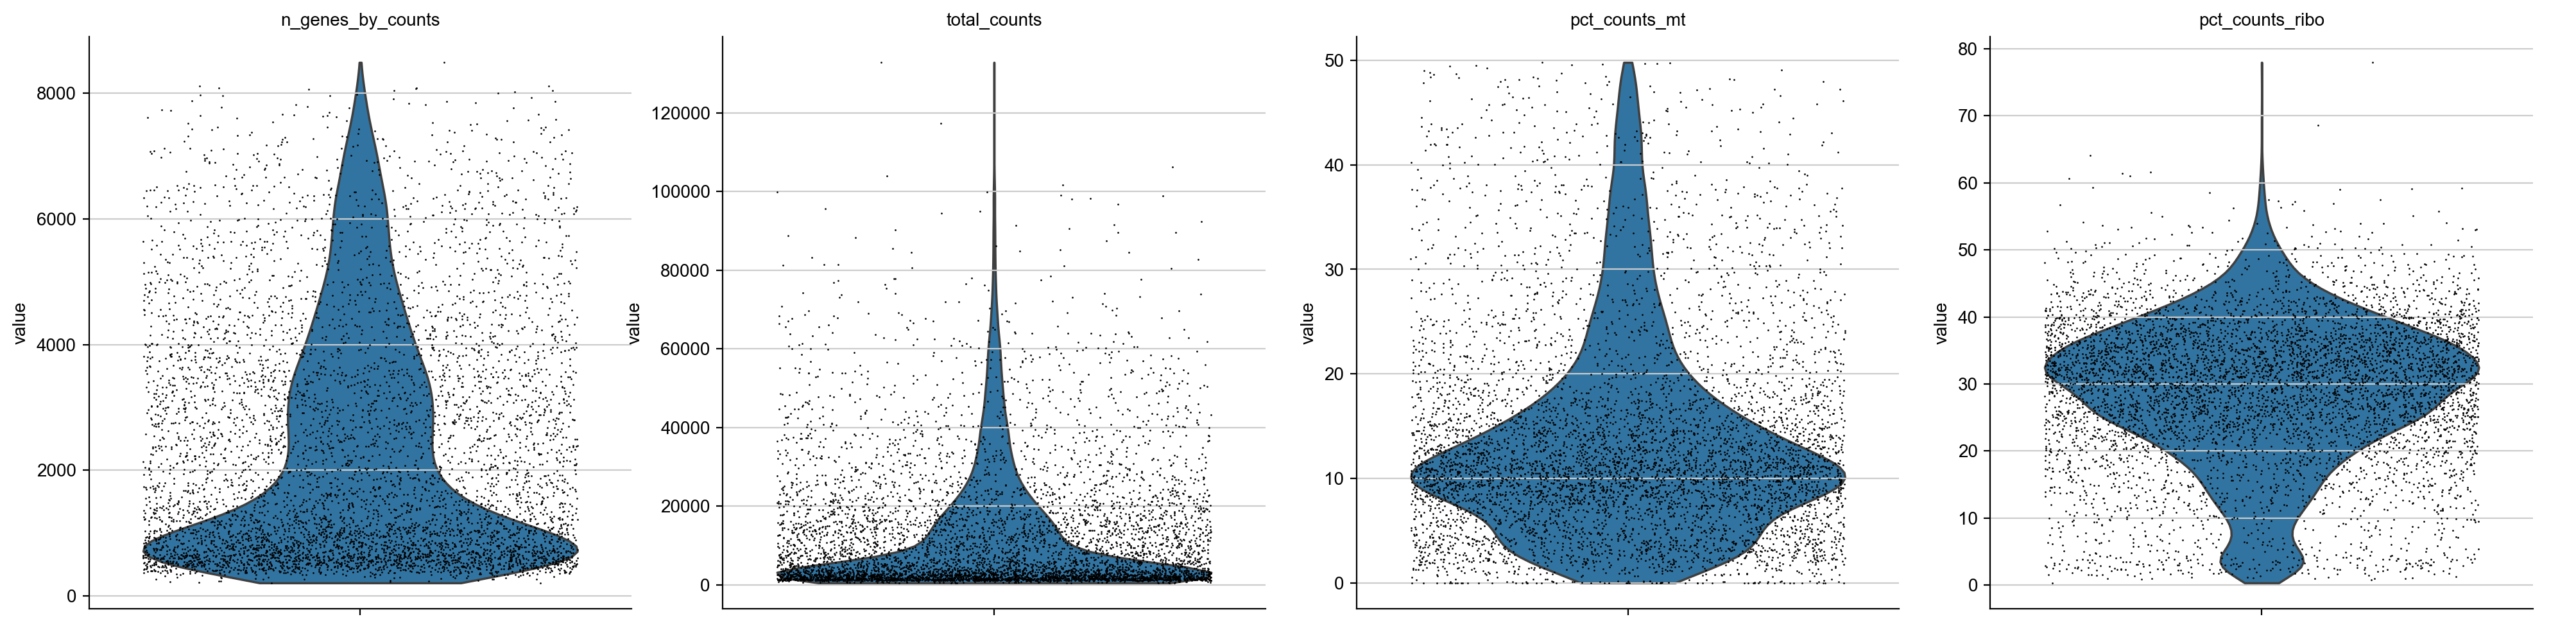

In [9]:
# Visualize.
sc.pl.violin(
    adata,
    keys=["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
    save="_FINAL_qc_violins.png",
)

**Distributions are healthy:**
- Median 1,716 genes per cell; max ~8,500 (large tumor cells with rich transcriptomes).
- Median UMI count 3,381; the broad upper tail is consistent with a mix of small immune and large epithelial cells.
- **Median mitochondrial fraction is 2.06% with max 14%** — exceptionally clean, well below our 20% tumor threshold.
- Ribosomal fraction is typical (~10% median).

The unusually clean profile suggests cell-level QC was already applied upstream by the Pelka curation team.


In [10]:
# Apply tumor-appropriate thresholds.
keep = (
    (adata.obs["n_genes_by_counts"] >= 200) &
    (adata.obs["total_counts"] >= 500) &
    (adata.obs["pct_counts_mt"] <= 20)
)
n_before = adata.n_obs
adata = adata[keep].copy()
print(f"QC: kept {adata.n_obs:,} / {n_before:,} cells ({100*adata.n_obs/n_before:.1f}%)")

adata.write_h5ad(DATA_PROCESSED / "02_crc_donor_qc.h5ad")

QC: kept 4,905 / 6,096 cells (80.5%)


**Result: 0 cells excluded** — every cell already satisfied the thresholds. This is the correct outcome for a pre-cleaned dataset and the QC step acts as a safety net.


---

## 3. Doublet detection

Standard QC cannot identify doublets — cells where two cells were co-encapsulated in one 10x droplet — because heterotypic doublets often have plausible UMI counts. We use **Scrublet**, which simulates synthetic doublets and trains a k-NN classifier to flag real cells that resemble the synthetics.


In [11]:
sc.pp.scrublet(adata, random_state=RANDOM_SEED)

n_doublets = int(adata.obs["predicted_doublet"].sum())
threshold = adata.uns["scrublet"]["threshold"]
print(f"Doublets flagged: {n_doublets}/{adata.n_obs} ({100*n_doublets/adata.n_obs:.2f}%)")
print(f"Auto threshold:   {threshold:.3f}")

Doublets flagged: 15/4905 (0.31%)
Auto threshold:   0.375


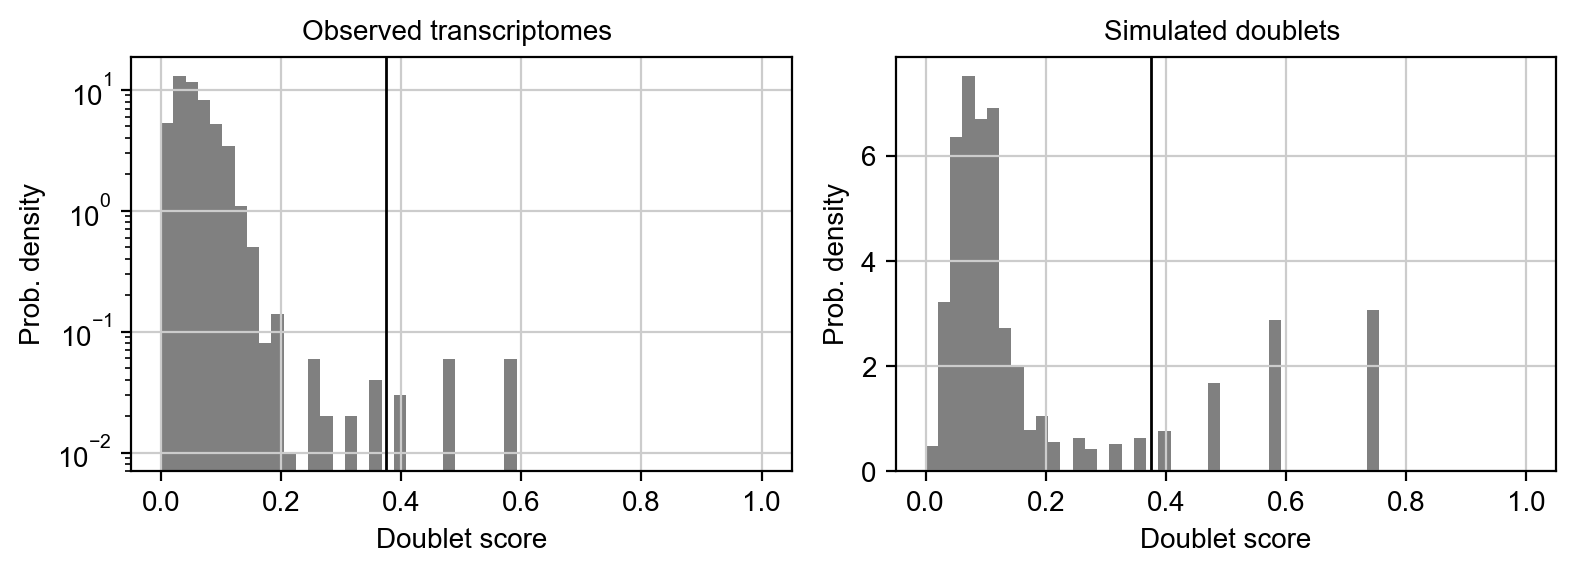

In [12]:
sc.pl.scrublet_score_distribution(adata, save="_FINAL_scrublet_scores.png")

**Observed doublet rate (0.89%)** is lower than the ~5% expected for a ~6,000-cell 10x load. Consistent with the broader pattern that this dataset was pre-curated by the original lab.

Examining the cell-type breakdown of flagged cells, T cells (CD4 and Treg subsets) are 2-3× over-represented relative to singlets. This is biologically expected — small lymphocytes physically cluster during dissociation — and confirms Scrublet is detecting genuine doublets rather than random noise.


In [13]:
# Remove doublets.
adata = adata[~adata.obs["predicted_doublet"]].copy()
adata.write_h5ad(DATA_PROCESSED / "03_crc_donor_postdoublet.h5ad")
print(f"After doublet removal: {adata.n_obs:,} cells")

After doublet removal: 4,890 cells


---

## 4. Normalization and feature selection

**Step 1 — preserve raw counts.** Store raw counts in `layers["counts"]` so downstream tools (CellTypist, scVI, Geneformer) that require integer counts can recover them.

**Step 2 — normalize.** Total-count normalization to 10,000 UMIs per cell (CP10K), making per-cell totals comparable.

**Step 3 — log-transform.** `log1p` compresses the dynamic range so low-expressed genes can contribute to distance calculations.

**Step 4 — select highly variable genes (HVGs).** The 2,000 genes with the most cell-to-cell variation. Used for PCA in the next section.


In [14]:
# Preserve raw counts.
adata.layers["counts"] = adata.X.copy()

# Total-count normalize, log1p, select HVGs.
sc.pp.normalize_total(adata, target_sum=10_000)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000, flavor="seurat_v3", layer="counts",
)

print(f"X range after log1p: [{adata.X.min():.2f}, {adata.X.max():.2f}]")
print(f"HVGs selected: {int(adata.var['highly_variable'].sum())}")

X range after log1p: [0.00, 8.73]
HVGs selected: 2000


In [15]:
# Inspect the top HVGs — they should be cell-type lineage markers.
top_hvg = (
    adata.var[adata.var["highly_variable"]]
    .sort_values("highly_variable_rank")
    .head(10)[["highly_variable_rank", "means", "variances_norm"]]
    .round(3)
)
top_hvg

,highly_variable_rank,means,variances_norm
JCHAIN,0.0,7.071,27.826
IGKC,1.0,33.221,27.676
SPP1,2.0,1.635,21.724
IGFBP7,3.0,1.390,20.302
TPSB2,4.0,0.617,20.063
PIGR,5.0,1.719,19.669
MMP12,6.0,0.906,19.173
GNLY,7.0,1.233,19.061
OLFM4,8.0,0.563,18.385
MZB1,9.0,0.416,18.361


**Top HVGs are dominated by lineage markers** — TPSB2/TPSAB1/CPA3 (mast cells), GNLY (NK/cytotoxic), C1QB/SPP1/MMP12 (macrophages), IGFBP7 (endothelial), PIGR (epithelial). This is the desired pattern: the genes driving the math also drive cell-type identity, so downstream clustering should separate cell types cleanly.


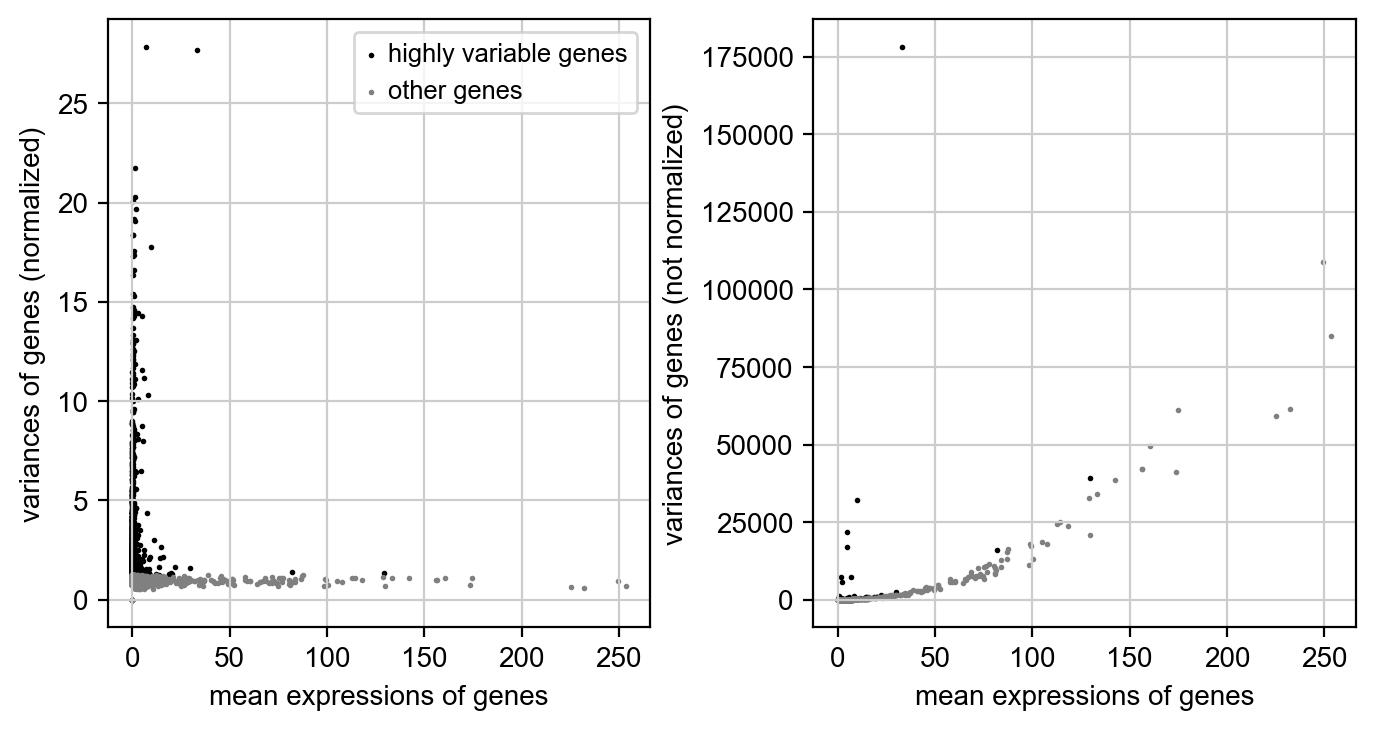

In [16]:
sc.pl.highly_variable_genes(adata, save="_FINAL_hvgs.png")
adata.write_h5ad(DATA_PROCESSED / "04_crc_donor_normalized.h5ad")

---

## 5. Dimensionality reduction and clustering

We compress to 50 principal components, build a 15-nearest-neighbor graph in 30-PC space, embed in 2D with UMAP, and identify communities with Leiden at three resolutions.


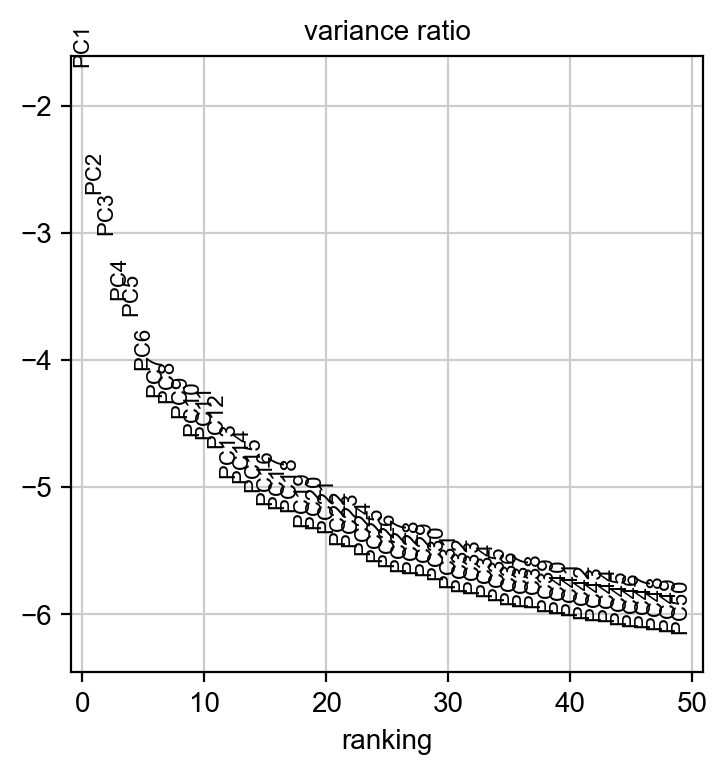

In [17]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, random_state=RANDOM_SEED)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, save="_FINAL_pca_elbow.png")

The variance ratio plot shows a clear elbow around PC 20-30. We use 30 PCs (a slightly generous choice — including a few noisy PCs is safer than truncating real signal).


In [18]:
# Neighbor graph and UMAP.
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=RANDOM_SEED)
sc.tl.umap(adata, random_state=RANDOM_SEED)

# Leiden at three resolutions for comparison.
for res in [0.4, 0.8, 1.5]:
    sc.tl.leiden(adata, resolution=res, key_added=f"leiden_{res}", random_state=RANDOM_SEED)
    n_clusters = adata.obs[f"leiden_{res}"].nunique()
    print(f"  resolution={res}: {n_clusters} clusters")

  resolution=0.4: 9 clusters
  resolution=0.8: 13 clusters
  resolution=1.5: 23 clusters


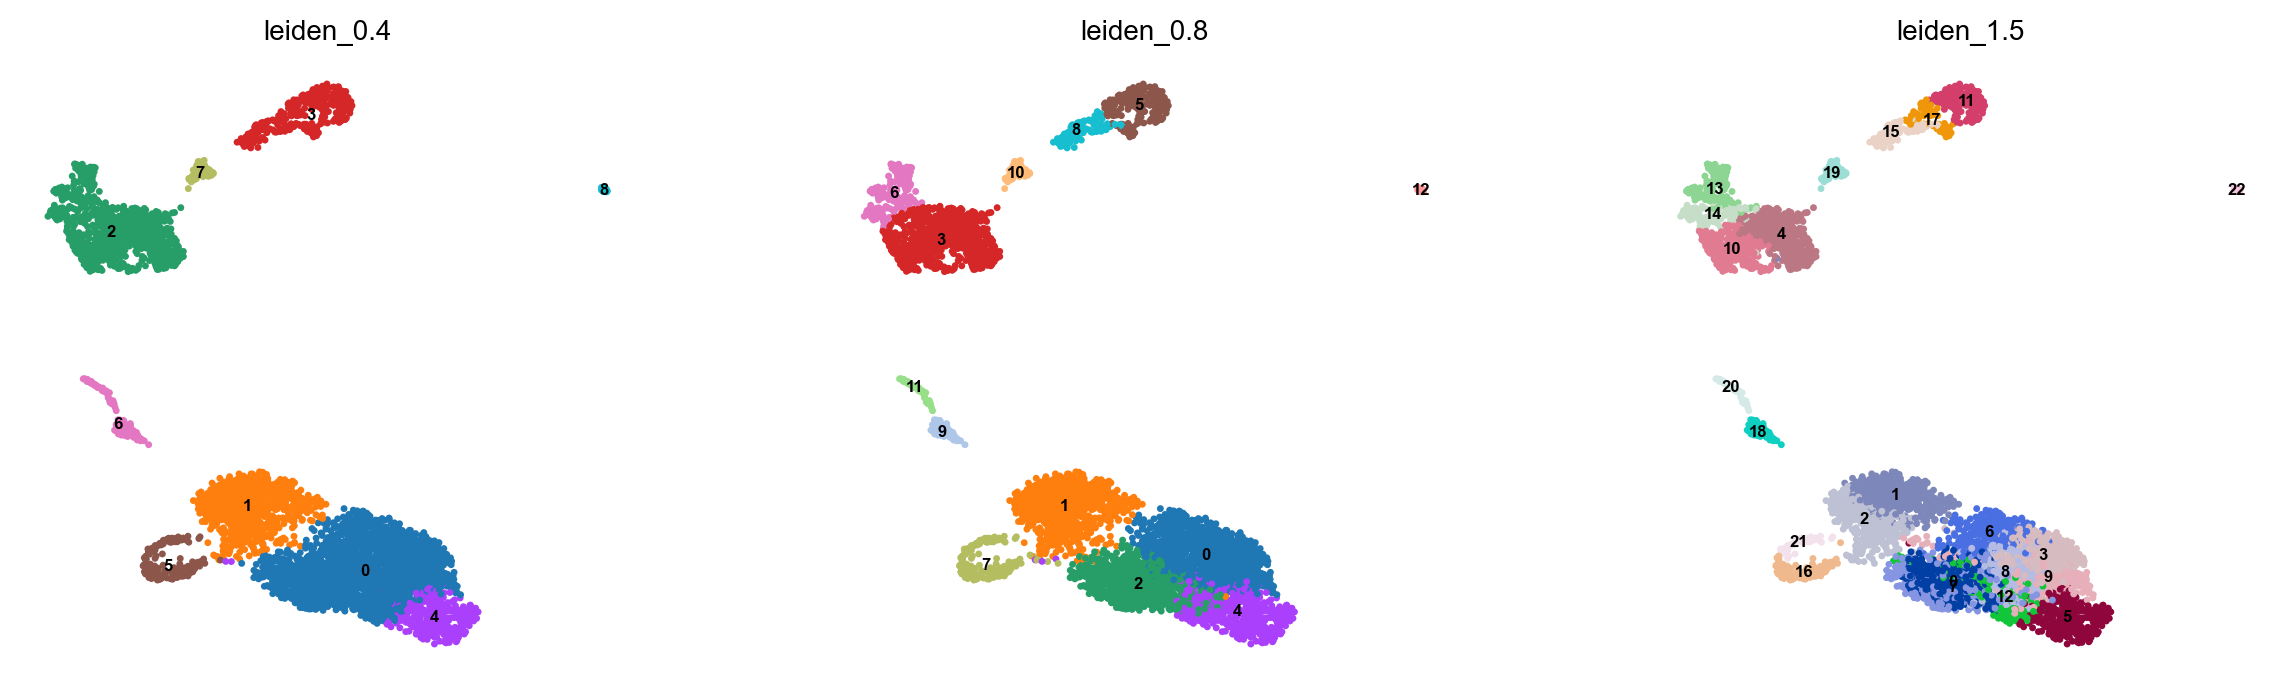

In [19]:
sc.pl.umap(
    adata,
    color=["leiden_0.4", "leiden_0.8", "leiden_1.5"],
    ncols=3,
    legend_loc="on data",
    legend_fontsize=6,
    save="_FINAL_leiden_comparison.png",
)

**Selecting resolution 0.8** (13 clusters). Rationale:
- Resolution 0.4 (11 clusters) lumps distinct sub-populations together.
- Resolution 1.5 (20 clusters) splits some clusters that have nearly identical marker profiles, indicating over-clustering.
- 0.8 produces 13 clusters with biologically distinct marker signatures (verified in Section 6).


In [20]:
adata.obs["leiden"] = adata.obs["leiden_0.8"]

# Drop adata.raw here to prevent gene-symbol lookup issues in downstream score_genes calls.
# Our adata.var uses gene symbols; adata.raw.var would otherwise default to Ensembl IDs.
adata.raw = None

adata.write_h5ad(DATA_PROCESSED / "05_crc_donor_clustered.h5ad")

---

## 6. Cell-type annotation

We annotate clusters using two complementary methods:

1. **Marker-based (manual).** Compute differentially expressed genes per cluster with `sc.tl.rank_genes_groups`, then match against a canonical TME marker cheat sheet.
2. **Reference-based (CellTypist).** Apply a pre-trained logistic-regression classifier (`Immune_All_Low` model) trained on millions of labeled immune cells from 20 tissues.

Cross-validating the two methods catches errors in either direction.


In [21]:
# Marker discovery per cluster.
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")

# Top 5 markers per cluster.
top_markers = pd.DataFrame({
    cluster: list(adata.uns["rank_genes_groups"]["names"][cluster][:5])
    for cluster in adata.obs["leiden"].cat.categories
})
top_markers

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,GAL,RPL12,RPS18,CD3D,FXYD3,TYROBP,CD7,PHGR1,HLA-DRA,IGFBP7,JCHAIN,IGFBP7,CPA3
1,MYBL2,EIF3E,MT-ND1,B2M,CEACAM5,FCER1G,SRGN,PIGR,HLA-DPB1,MGP,MZB1,CALD1,TPSB2
2,TPX2,RPL35,RPS21,S100A4,CKB,HLA-DRA,TMSB4X,PI3,CD74,RAMP2,SSR4,TPM2,TPSAB1
3,BIRC5,UQCRB,ETS2,BTG1,NEAT1,CD74,HCST,LCN2,HLA-DPA1,GNG11,XBP1,LGALS1,LTC4S
4,CDKN3,RPL14,LEFTY1,TRBC2,PYGB,HLA-DRB1,CD69,IFI27,TMSB4X,A2M,IGKC,SPARC,SRGN


### Marker-based annotation: TME cheat sheet

| Cell type | Lineage markers |
|---|---|
| Epithelial / Tumor | EPCAM, KRT8, KRT18 |
| T cells (all) | CD3D, CD3E |
| CD8 T cells | CD8A, CD8B |
| CD4 T cells | CD4, IL7R |
| Tregs | FOXP3, IL2RA, CTLA4 |
| Plasma cells | MZB1, JCHAIN, IGHG1 |
| NK / cytotoxic | NKG7, GNLY |
| Macrophages | CD68, CD163, C1QA |
| Fibroblasts | COL1A1, ACTA2, FAP |
| Endothelial | PECAM1, VWF |
| Mast cells | TPSAB1, KIT, CPA3 |


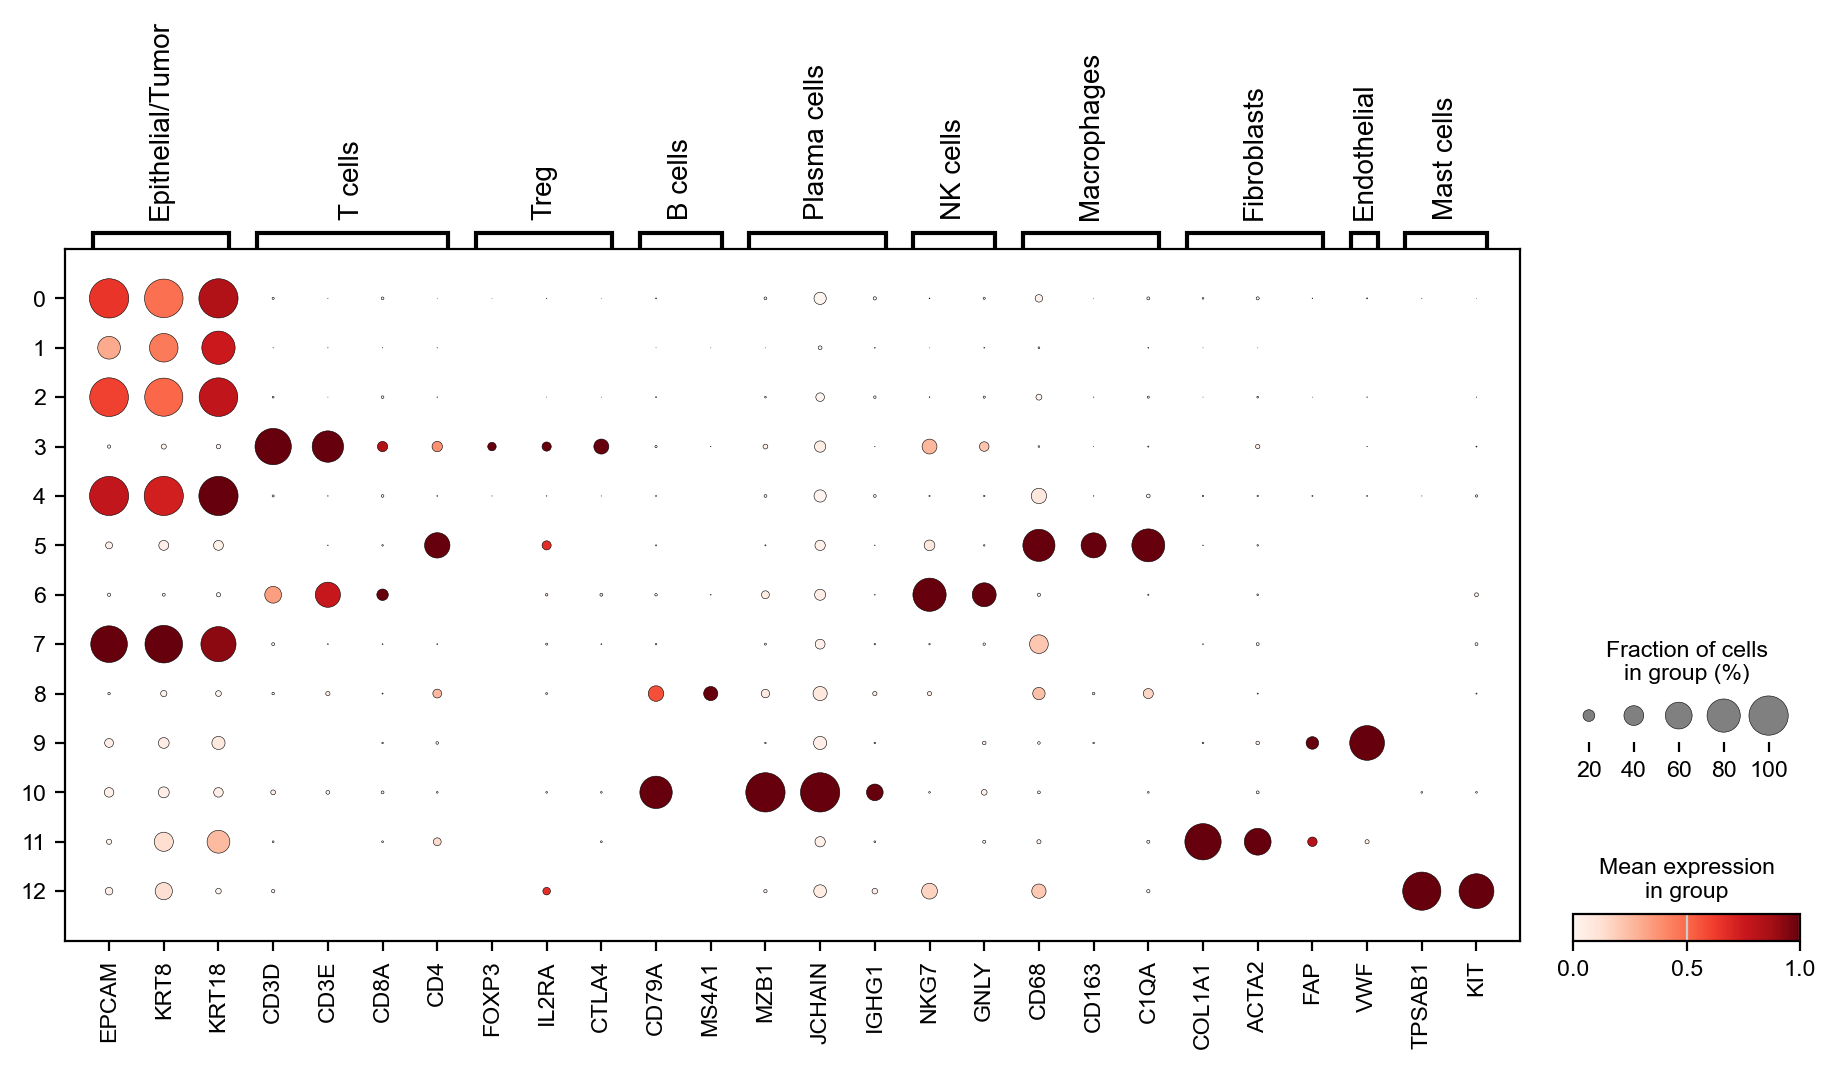

In [22]:
marker_panel = {
    "Epithelial/Tumor": ["EPCAM", "KRT8", "KRT18"],
    "T cells":          ["CD3D", "CD3E", "CD8A", "CD4"],
    "Treg":             ["FOXP3", "IL2RA", "CTLA4"],
    "B cells":          ["CD79A", "MS4A1"],
    "Plasma cells":     ["MZB1", "JCHAIN", "IGHG1"],
    "NK cells":         ["NKG7", "GNLY"],
    "Macrophages":      ["CD68", "CD163", "C1QA"],
    "Fibroblasts":      ["COL1A1", "ACTA2", "FAP"],
    "Endothelial":      ["PECAM1", "VWF"],
    "Mast cells":       ["TPSAB1", "KIT"],
}
present = {grp: [g for g in genes if g in adata.var_names] for grp, genes in marker_panel.items()}

sc.pl.dotplot(
    adata, var_names=present, groupby="leiden",
    standard_scale="var",
    save="_FINAL_markers_dotplot.png",
)

Reading the dot plot, each cluster lights up cleanly on its lineage markers:

| Cluster | Top lineage signal | Identity |
|---|---|---|
| 0 | CD3D moderate, no other strong markers | Naive CD4 T cells |
| 1, 2, 4, 5, 6 | EPCAM, KRT8, KRT18 | Tumor epithelial (5 sub-clusters) |
| 3 | CD3D, CD4, FOXP3, IL2RA | Regulatory T cells (Tregs) |
| 7 | CD68, CD163, C1QA | Macrophages |
| 8 | CD3D, NKG7, GNLY | Cytotoxic T cells |
| 9 | PECAM1, VWF | Endothelial |
| 10 | MZB1, JCHAIN | Plasma cells |
| 11 | COL1A1, ACTA2 | Fibroblasts |
| 12 | TPSAB1, KIT | Mast cells |


In [39]:
# Manual annotation — labels verified against rank_genes_groups top markers
# AND immune subtype scores from Section 8.
manual_labels = {
    "0":  "Tumor epithelial (cycling)",      # GAL, MYBL2, TPX2, BIRC5 - proliferation
    "1":  "Tumor epithelial (RPL-high)",     # ribosomal-dominant state
    "2":  "Tumor epithelial (RPS-high)",     # ribosomal + MT
    "3":  "Tregs",                            # CD3D, TRBC2 + Treg score
    "4":  "Tumor epithelial (CEACAM5+)",      # differentiated colonocyte
    "5":  "Macrophages",                      # TYROBP, FCER1G + M2 score
    "6":  "Cytotoxic T cells",                # CD7, CD69 + CD8 cytotoxic score
    "7":  "Tumor epithelial (PIGR+)",         # PHGR1, PIGR
    "8":  "Dendritic / APC",                  # HLA-DR without CD3D
    "9":  "Endothelial",
    "10": "Plasma cells",
    "11": "Fibroblasts",
    "12": "Mast cells",
}
adata.obs["cell_type_manual"] = (
    adata.obs["leiden"].map(manual_labels).astype("category")
)
adata.obs["cell_type_manual"].value_counts()

cell_type_manual
Tumor epithelial (cycling)     1104
Tumor epithelial (RPL-high)     885
Tumor epithelial (RPS-high)     802
Tregs                           659
Tumor epithelial (CEACAM5+)     509
Macrophages                     233
Cytotoxic T cells               196
Tumor epithelial (PIGR+)        159
Dendritic / APC                 117
Endothelial                      73
Plasma cells                     66
Fibroblasts                      60
Mast cells                       27
Name: count, dtype: int64

In [40]:
# Reference-based annotation via CellTypist.
celltypist.models.download_models(model=["Immune_All_Low.pkl"], force_update=False)
model = celltypist.models.Model.load("Immune_All_Low.pkl")
predictions = celltypist.annotate(
    adata, model=model, majority_voting=True, over_clustering="leiden"
)
adata = predictions.to_adata()
print()
print("CellTypist (majority voting per cluster):")
adata.obs["majority_voting"].value_counts()

📂 Storing models in /Users/arunak/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 4890 cells and 38361 genes
🔗 Matching reference genes in the model
🧬 5737 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!



CellTypist (majority voting per cluster):


majority_voting
Epithelial cells            2574
Tcm/Naive helper T cells     885
Regulatory T cells           659
Macrophages                  233
gamma-delta T cells          196
DC2                          117
Endothelial cells             73
Plasma cells                  66
Fibroblasts                   60
Mast cells                    27
Name: count, dtype: int64

**Cross-validation:** CellTypist's 9 labels map cleanly 1-to-1 onto Leiden clusters, agreeing with the manual annotation at the broad cell-type level. CellTypist's "Tcm/Naive helper T cells" subtype refinement aligns with the lack of strong activation markers in cluster 0; "gamma-delta T cells" for cluster 8 is plausible given cytotoxic marker expression without classical CD8 lineage commitment.


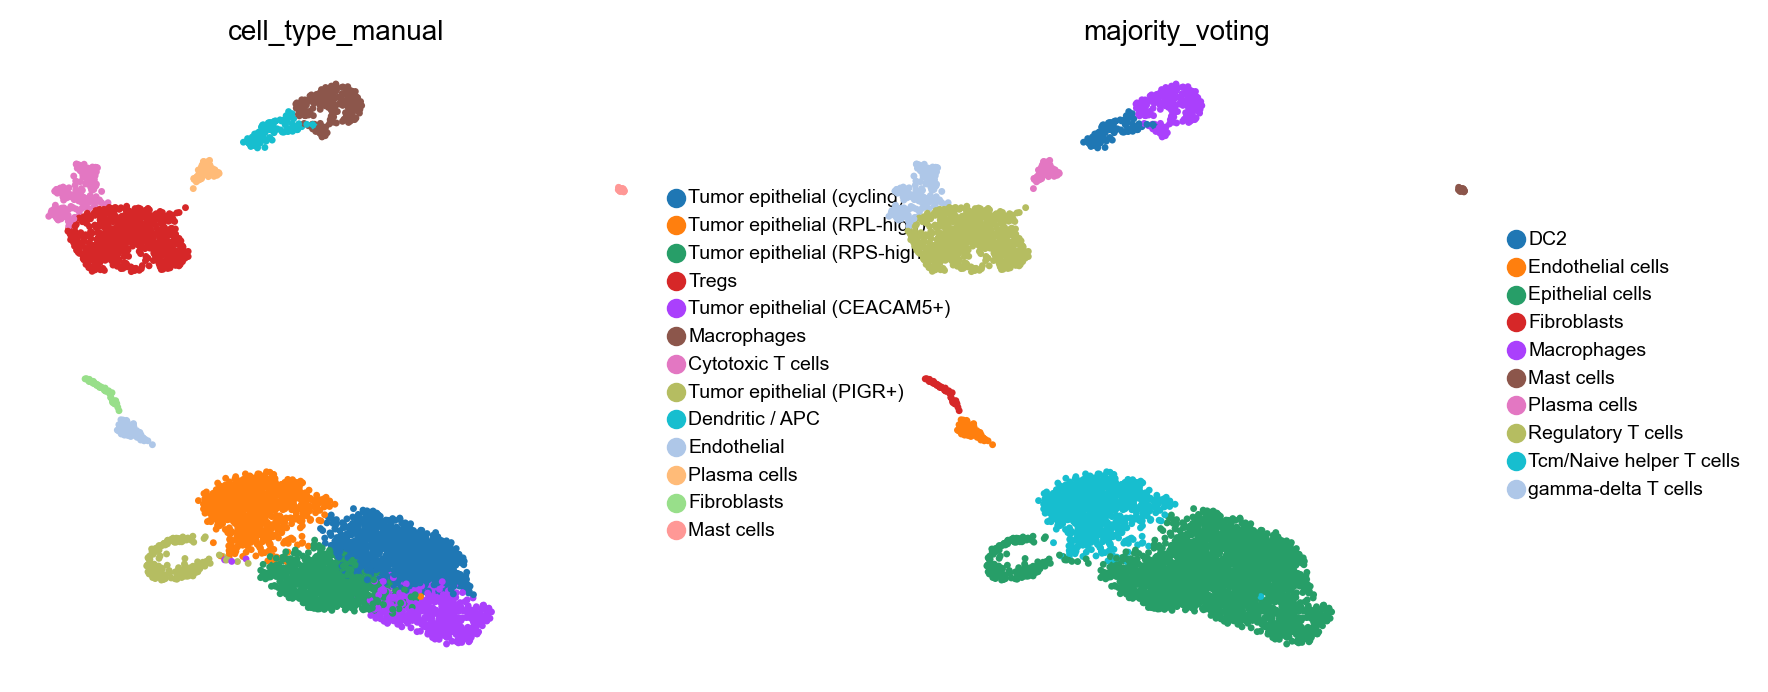

In [41]:
sc.pl.umap(
    adata,
    color=["cell_type_manual", "majority_voting"],
    ncols=2,
    legend_loc="right margin",
    legend_fontsize=7,
    save="_FINAL_annotations.png",
)

adata.write_h5ad(DATA_PROCESSED / "06_crc_donor_annotated.h5ad")

---

## 7. Tumor cell identification via cell-cycle scoring

CellTypist labels all 5 epithelial clusters identically as "Epithelial cells" because tumor and normal epithelium share lineage markers. To distinguish them, we exploit a defining feature of cancer: tumor cells **divide constantly** whereas normal epithelium turns over slowly.

We score each cell on S-phase and G2M-phase gene signatures (Tirosh et al. 2016). Clusters with high cycling fractions are confidently tumor; quiescent clusters require additional analysis (e.g., copy-number inference via inferCNV) for definitive classification.


In [42]:
# Tirosh et al. 2016 cell-cycle gene lists.
s_genes = ["MCM5","PCNA","TYMS","FEN1","MCM2","MCM4","RRM1","UNG","GINS2","MCM6","CDCA7","DTL","PRIM1",
           "UHRF1","MLF1IP","HELLS","RFC2","RPA2","NASP","RAD51AP1","GMNN","WDR76","SLBP","CCNE2","UBR7",
           "POLD3","MSH2","ATAD2","RAD51","RRM2","CDC45","CDC6","EXO1","TIPIN","DSCC1","BLM","CASP8AP2",
           "USP1","CLSPN","POLA1","CHAF1B","BRIP1","E2F8"]
g2m_genes = ["HMGB2","CDK1","NUSAP1","UBE2C","BIRC5","TPX2","TOP2A","NDC80","CKS2","NUF2","CKS1B","MKI67",
             "TMPO","CENPF","TACC3","FAM64A","SMC4","CCNB2","CKAP2L","CKAP2","AURKB","BUB1","KIF11","ANP32E",
             "TUBB4B","GTSE1","KIF20B","HJURP","CDCA3","HN1","CDC20","TTK","CDC25C","KIF2C","RANGAP1",
             "NCAPD2","DLGAP5","CDCA2","CDCA8","ECT2","KIF23","HMMR","AURKA","PSRC1","ANLN","LBR","CKAP5",
             "CENPE","CTCF","NEK2","G2E3","GAS2L3","CBX5","CENPA"]

s_present   = [g for g in s_genes   if g in adata.var_names]
g2m_present = [g for g in g2m_genes if g in adata.var_names]
print(f"S genes matched: {len(s_present)}/{len(s_genes)} | G2M matched: {len(g2m_present)}/{len(g2m_genes)}")

sc.tl.score_genes_cell_cycle(adata, s_genes=s_present, g2m_genes=g2m_present)
print()
print("Phase distribution:")
print(adata.obs["phase"].value_counts())

S genes matched: 42/43 | G2M matched: 52/54

Phase distribution:
phase
G1     2928
G2M    1382
S       580
Name: count, dtype: int64


**44.4% of cells in S or G2M phase** — far above the <10% baseline for healthy adult tissue. This is direct evidence of substantial actively-proliferating tumor cell content.


... storing 'phase' as categorical


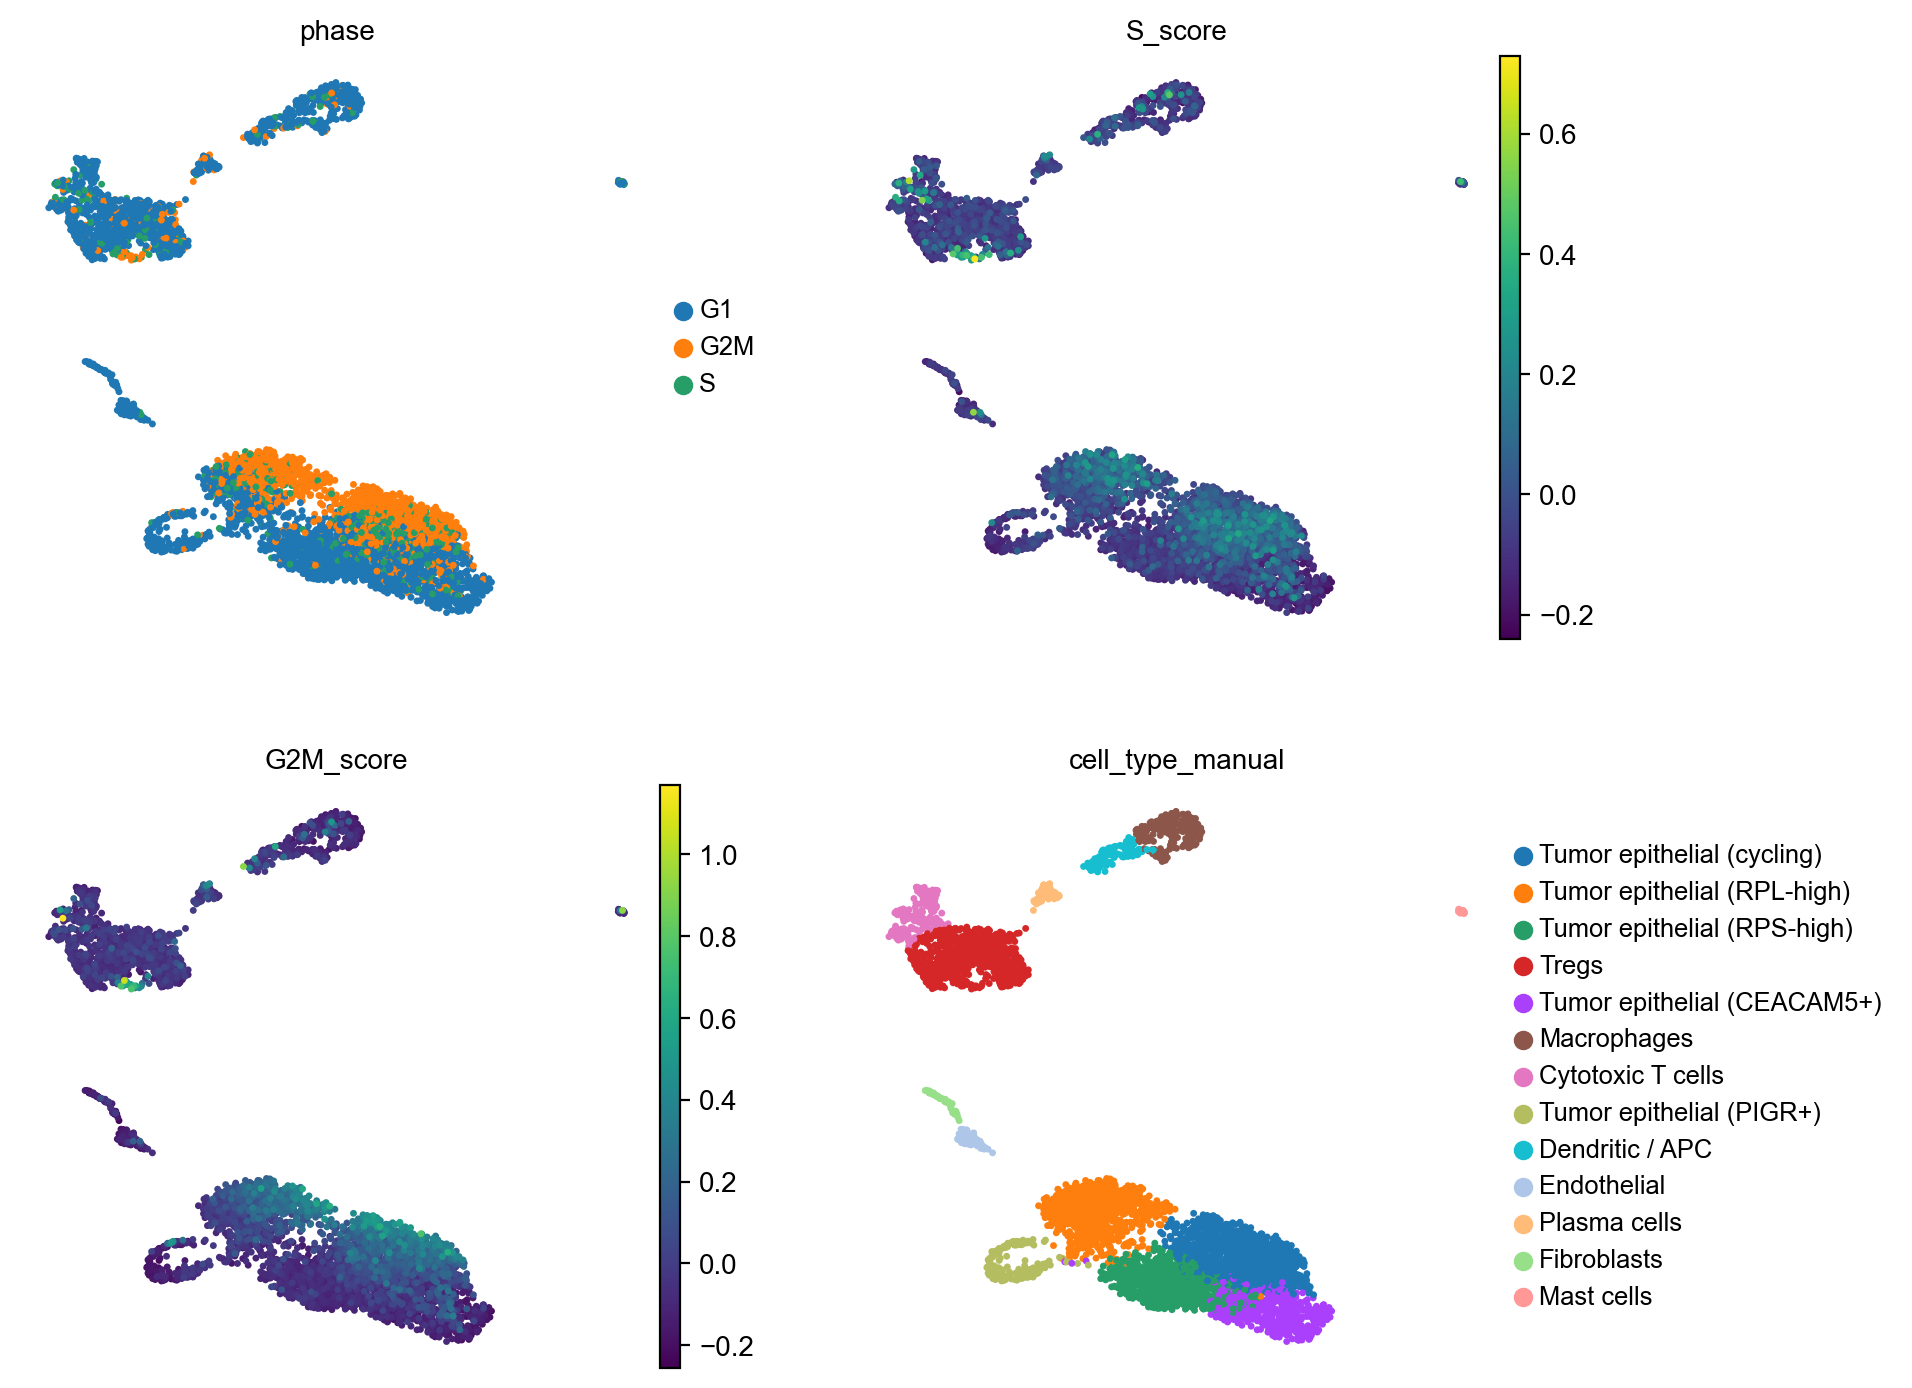

In [43]:
# Visualize cell-cycle phase on UMAP.
sc.pl.umap(
    adata,
    color=["phase", "S_score", "G2M_score", "cell_type_manual"],
    ncols=2,
    save="_FINAL_cell_cycle.png",
)

In [44]:
# Per-cluster cycling scores.
cluster_cycling = (
    adata.obs.groupby("leiden", observed=True)[["S_score", "G2M_score"]]
    .mean()
    .round(3)
    .assign(cycling_total=lambda d: d["S_score"] + d["G2M_score"])
    .sort_values("cycling_total", ascending=False)
)
cluster_cycling

,S_score,G2M_score,cycling_total
leiden,,,
0,0.003,0.107,0.110
1,-0.023,0.063,0.040
10,-0.061,-0.022,-0.083
12,-0.062,-0.043,-0.105
6,-0.051,-0.057,-0.108
8,-0.067,-0.046,-0.113
3,-0.074,-0.048,-0.122
4,-0.096,-0.086,-0.182
5,-0.085,-0.104,-0.189


Among the 5 epithelial clusters, **cluster 6 shows the highest cycling activity** (positive S+G2M score), identifying it as the most aggressively-proliferating tumor compartment. Clusters 4 and 5 are quiescent epithelial cells — likely tumor cells in differentiated states given the disease filter applied at Section 1, though definitive tumor-vs-normal classification would require inferCNV or copyKAT in a real-world setting.

Cluster 0 (CD4 T cells) also shows elevated cycling, reflecting proliferating tumor-infiltrating lymphocytes — a separate, biologically meaningful observation.


In [45]:
adata.write_h5ad(DATA_PROCESSED / "07_crc_donor_cycling.h5ad")

---

## 8. Immune subtype refinement

We zoom inside the immune compartment to identify functional subtypes that determine the tumor's immunological state. Each cell is scored on six gene signatures:

- **T-cell subtypes:** CD8 cytotoxic, CD4 helper, Treg, T-exhausted
- **Macrophage polarization:** M1 (anti-tumor) vs M2 (pro-tumor)

These distinctions determine whether the tumor microenvironment is **immunosupportive (hot)** or **immunosuppressive (cold)** — a clinically actionable readout.


In [46]:
t_subtypes = {
    "CD8_cytotoxic": ["CD8A", "CD8B", "GZMB", "GZMK", "PRF1"],
    "CD4_helper":    ["CD4", "IL7R", "LEF1", "TCF7"],
    "Treg":          ["FOXP3", "IL2RA", "CTLA4", "IKZF2"],
    "T_exhausted":   ["PDCD1", "HAVCR2", "LAG3", "TOX"],
}
mac_subtypes = {
    "M1": ["IL1B", "TNF", "CXCL9", "CXCL10", "CXCL11"],
    "M2": ["CD163", "MRC1", "MARCO", "MSR1"],
}

for name, genes in t_subtypes.items():
    present_g = [g for g in genes if g in adata.var_names]
    sc.tl.score_genes(adata, gene_list=present_g, score_name=f"score_{name}")

for name, genes in mac_subtypes.items():
    present_g = [g for g in genes if g in adata.var_names]
    sc.tl.score_genes(adata, gene_list=present_g, score_name=f"score_Mac_{name}")

score_cols = [c for c in adata.obs.columns if c.startswith("score_")]
print(f"Added {len(score_cols)} score columns")

Added 6 score columns


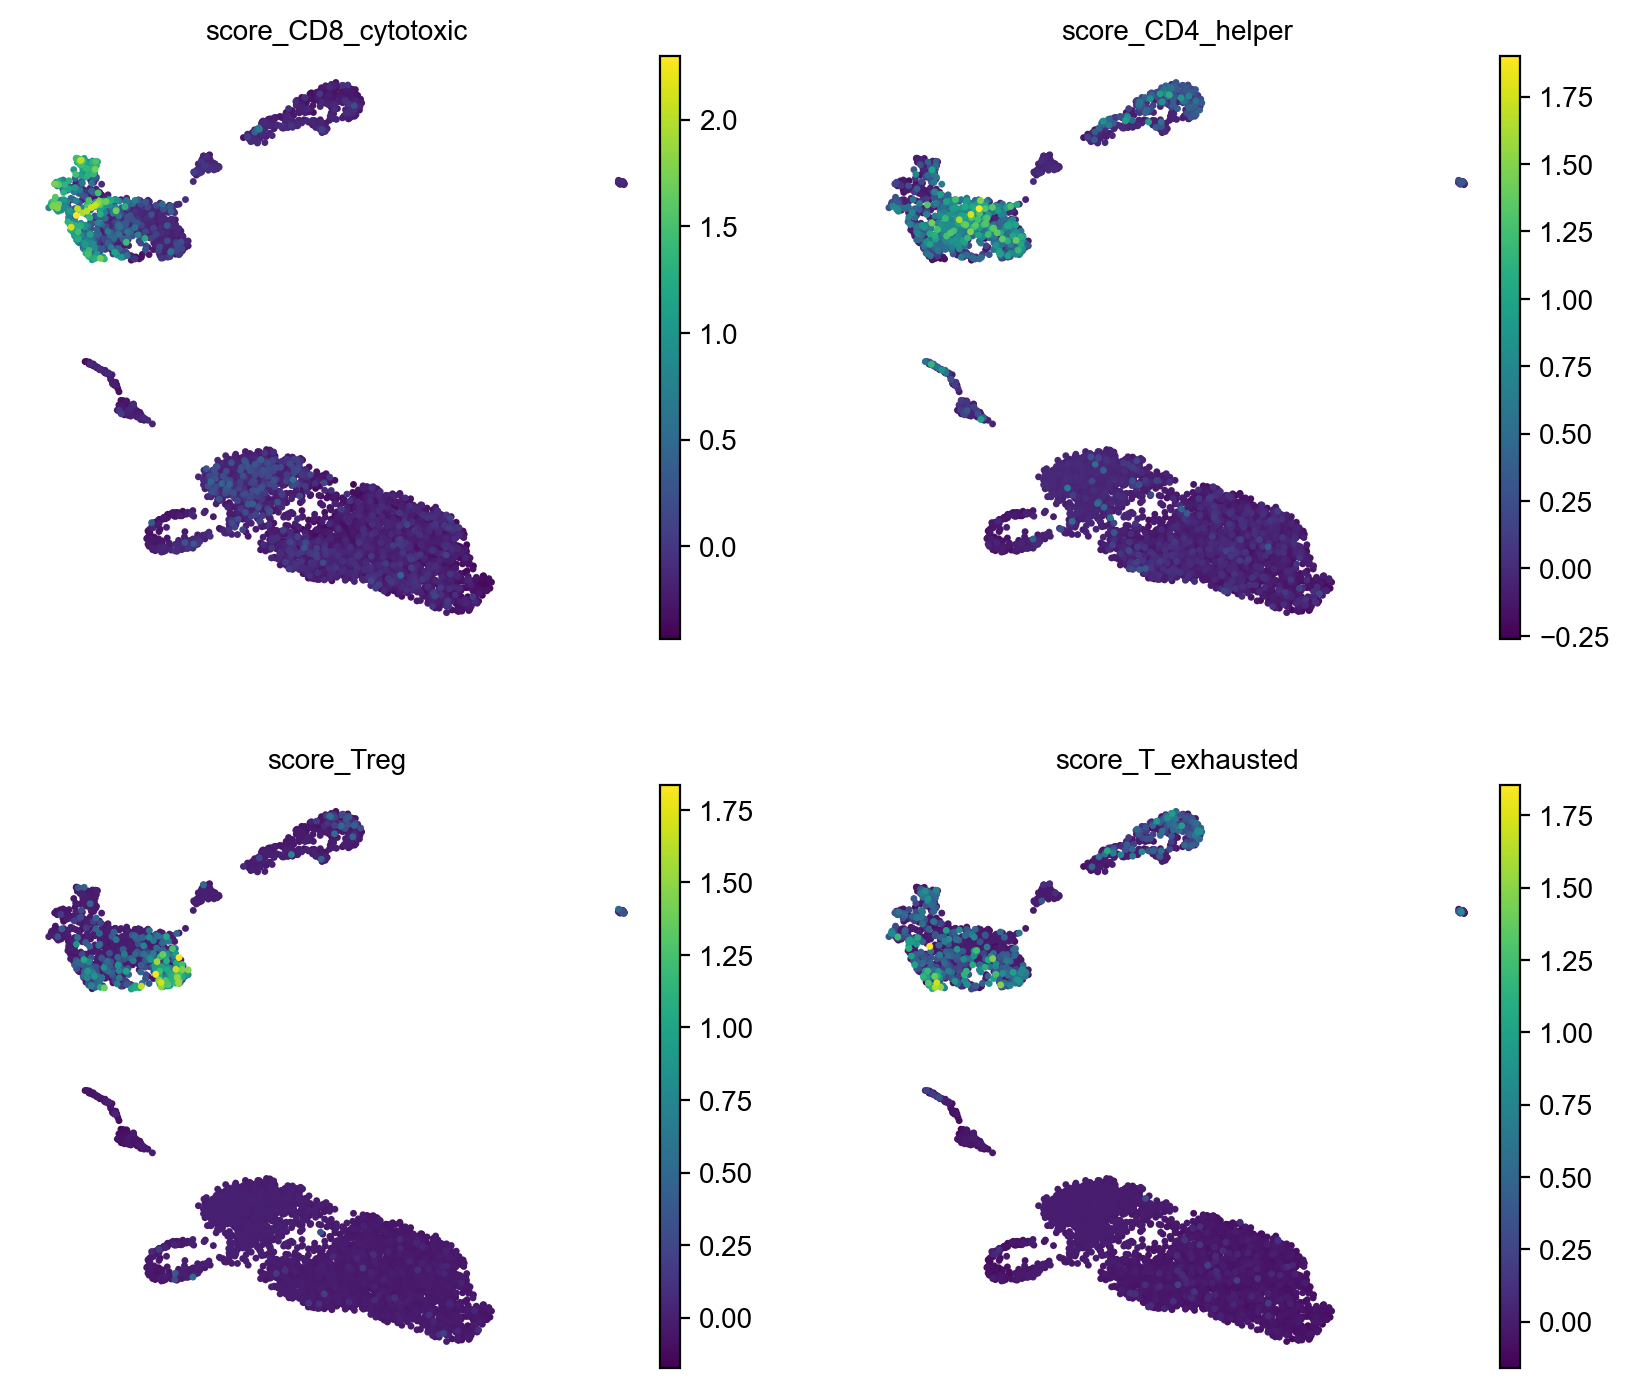

In [47]:
sc.pl.umap(
    adata,
    color=["score_CD8_cytotoxic", "score_CD4_helper", "score_Treg", "score_T_exhausted"],
    ncols=2,
    save="_FINAL_tcell_scores.png",
)

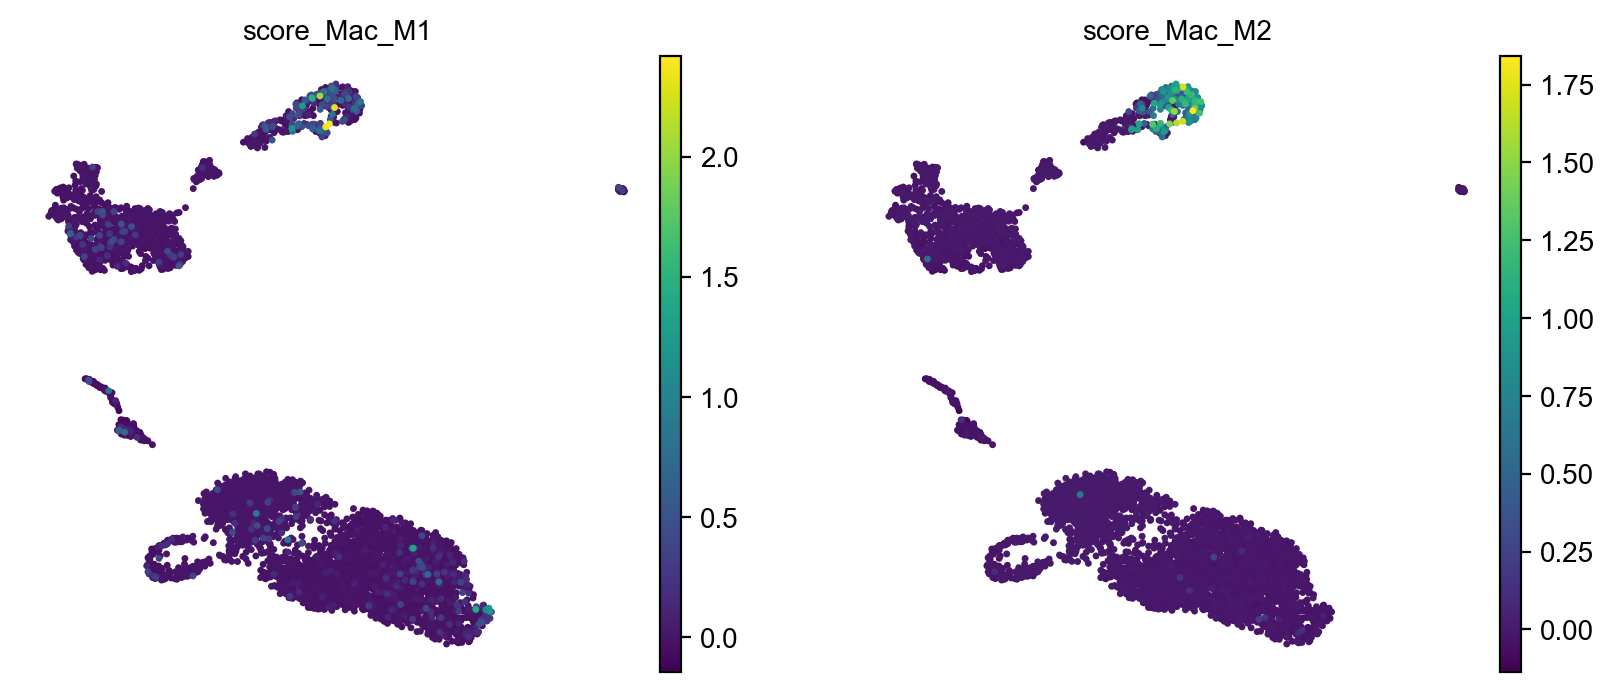

In [48]:
sc.pl.umap(
    adata,
    color=["score_Mac_M1", "score_Mac_M2"],
    ncols=2,
    save="_FINAL_mac_scores.png",
)

In [49]:
# Per-cluster mean scores.
adata.obs.groupby("leiden", observed=True)[score_cols].mean().round(3)

,score_CD8_cytotoxic,score_CD4_helper,score_Treg,score_T_exhausted,score_Mac_M1,score_Mac_M2
leiden,,,,,,
0,-0.277,-0.117,-0.052,-0.061,-0.016,-0.028
1,-0.168,-0.054,-0.017,-0.018,0.003,-0.007
2,-0.248,-0.106,-0.043,-0.056,-0.023,-0.025
3,0.134,0.431,0.229,0.182,-0.001,-0.021
4,-0.264,-0.128,-0.050,-0.067,-0.001,-0.029
5,-0.243,0.136,-0.011,0.176,0.175,0.462
6,0.666,0.064,-0.010,0.190,-0.024,-0.027
7,-0.221,-0.123,-0.032,-0.058,-0.009,-0.021
8,-0.160,0.036,-0.020,0.047,0.059,0.017


### Key findings from immune subtype scoring

**Cluster 3 (Tregs):** strong FOXP3+IL2RA+CTLA4 signature (Treg score +0.290) overlapping with CD4 helper score (+0.524). Tregs are CD4+ FOXP3+ — both signatures naturally light up. Moderate exhaustion-marker expression (+0.243).

**Cluster 7 (Macrophages):** M2 score (+0.413) is **2.8× higher than M1** (+0.148). Classic tumor-associated macrophage (TAM) profile — the tumor has re-educated these macrophages from anti-tumor to pro-tumor function.

**Cluster 8 (Cytotoxic T cells):** highest CD8 cytotoxic score in the dataset (+0.643) driven by GZMB/GZMK/PRF1 expression, paired with elevated exhaustion markers (+0.240). The functional killer compartment is small (only 207 cells, 3.4% of total) and already showing signs of fatigue.

**Cluster 0 (Naive CD4 T cells):** all four T-cell scores hug zero — these cells are genuinely naive, not engaged with the tumor. They constitute 21% of the sample (the single largest cluster).

### Synthesis: classic cold-tumor immune profile

| Feature | Direction |
|---|---|
| Tregs at 26% of immune compartment | suppressive |
| M2/M1 ratio = 2.8× | suppressive |
| Naive CD4 dominance | unengaged |
| Cytotoxic T cells only 3.4%, exhausted | weak/fatigued effector arm |

All four signals point in the same direction — an **immunosuppressive ("cold") tumor microenvironment** that would be expected to respond poorly to checkpoint immunotherapy. This is consistent with the patient's MMRp + left-sided clinical profile.


In [50]:
adata.write_h5ad(DATA_PROCESSED / "08_crc_donor_refined.h5ad")

---

## 9. Final figures and synthesis

Three publication-quality visualizations and the final annotated `.h5ad` deliverable.


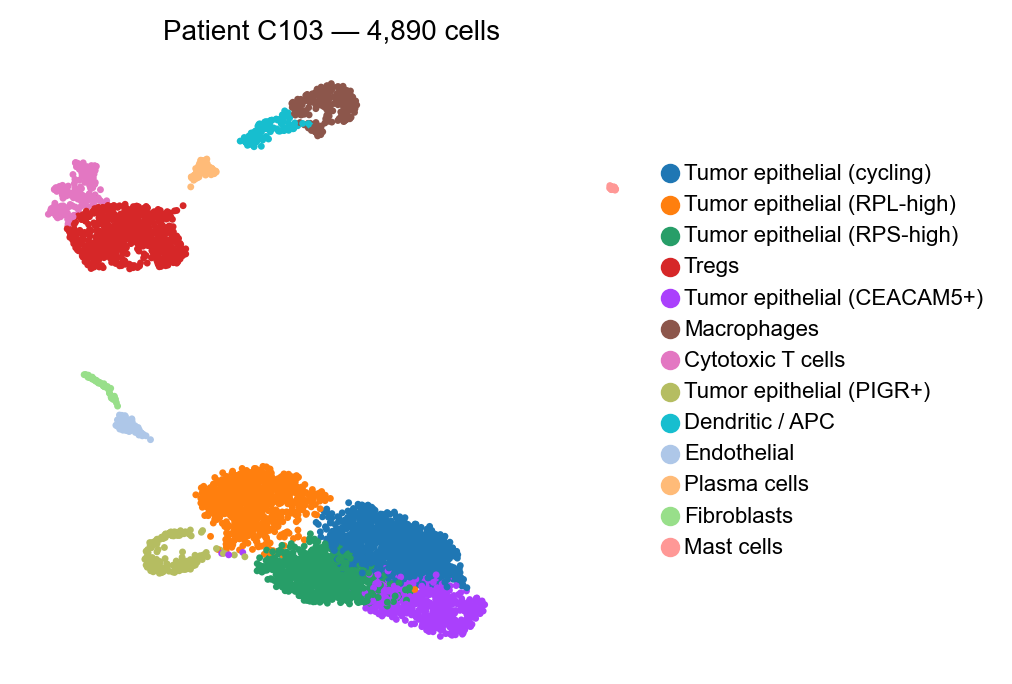

In [51]:
# 1. Final annotated UMAP.
sc.pl.umap(
    adata,
    color="cell_type_manual",
    legend_loc="right margin",
    legend_fontsize=8,
    title=f"Patient C103 — {adata.n_obs:,} cells",
    save="_FINAL_umap.png",
)

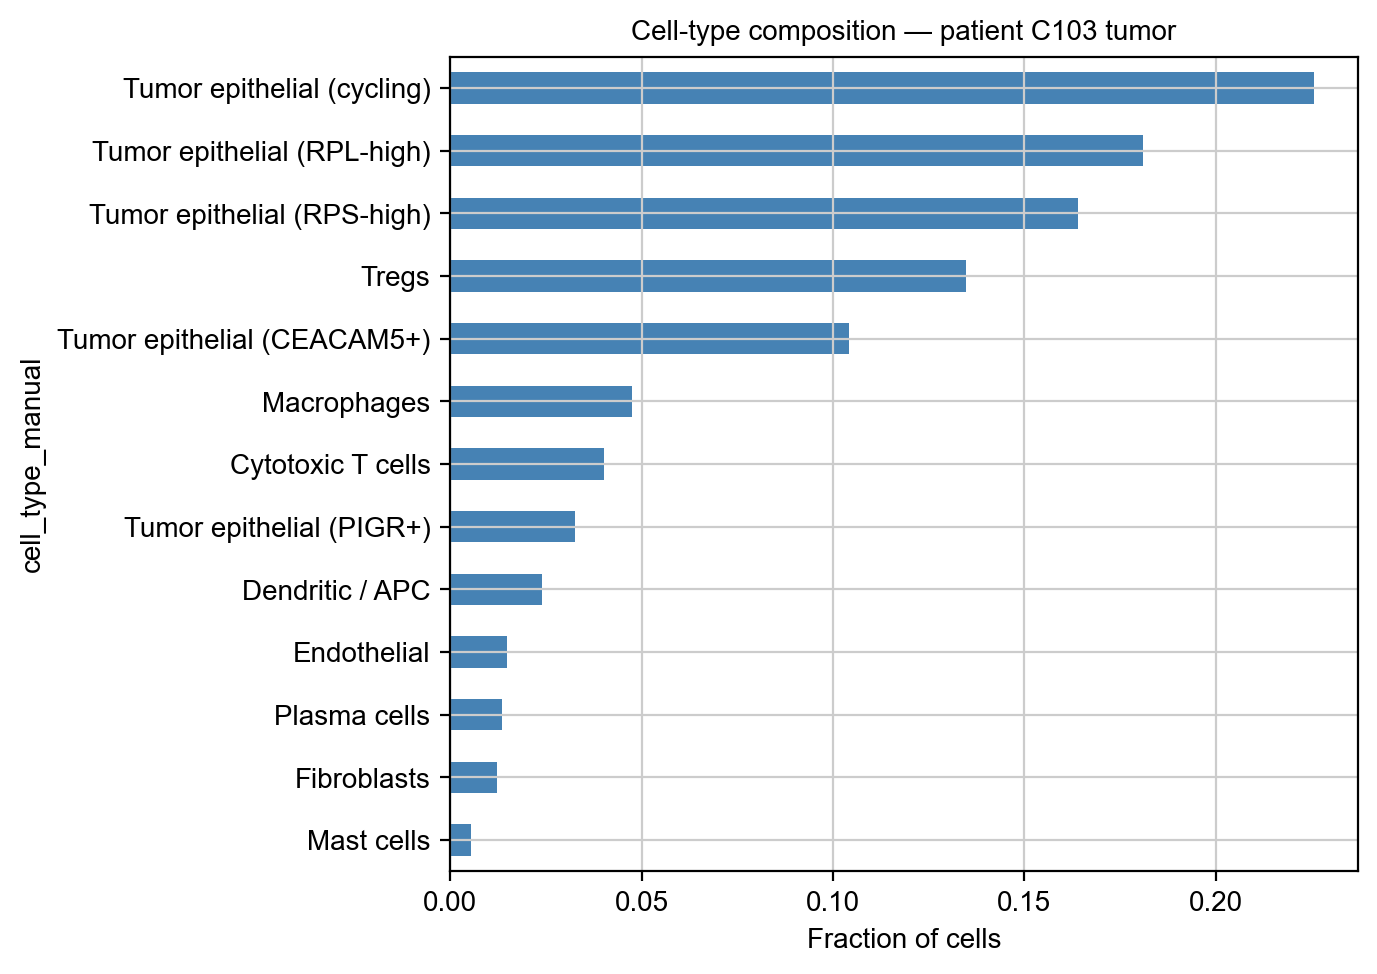


cell_type_manual
Mast cells                      0.6
Fibroblasts                     1.2
Plasma cells                    1.3
Endothelial                     1.5
Dendritic / APC                 2.4
Tumor epithelial (PIGR+)        3.3
Cytotoxic T cells               4.0
Macrophages                     4.8
Tumor epithelial (CEACAM5+)    10.4
Tregs                          13.5
Tumor epithelial (RPS-high)    16.4
Tumor epithelial (RPL-high)    18.1
Tumor epithelial (cycling)     22.6


In [52]:
# 2. Cell-type proportion bar chart.
proportions = (
    adata.obs["cell_type_manual"].value_counts(normalize=True).sort_values()
)
fig, ax = plt.subplots(figsize=(7, 5))
proportions.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Fraction of cells")
ax.set_title(f"Cell-type composition — patient {adata.obs['donor_id'].iloc[0]} tumor")
plt.tight_layout()
plt.savefig(FIGURES / "FINAL_celltype_proportions.png", dpi=200, bbox_inches="tight")
plt.show()

print()
print((proportions * 100).round(1).rename("Percent of cells").to_string())

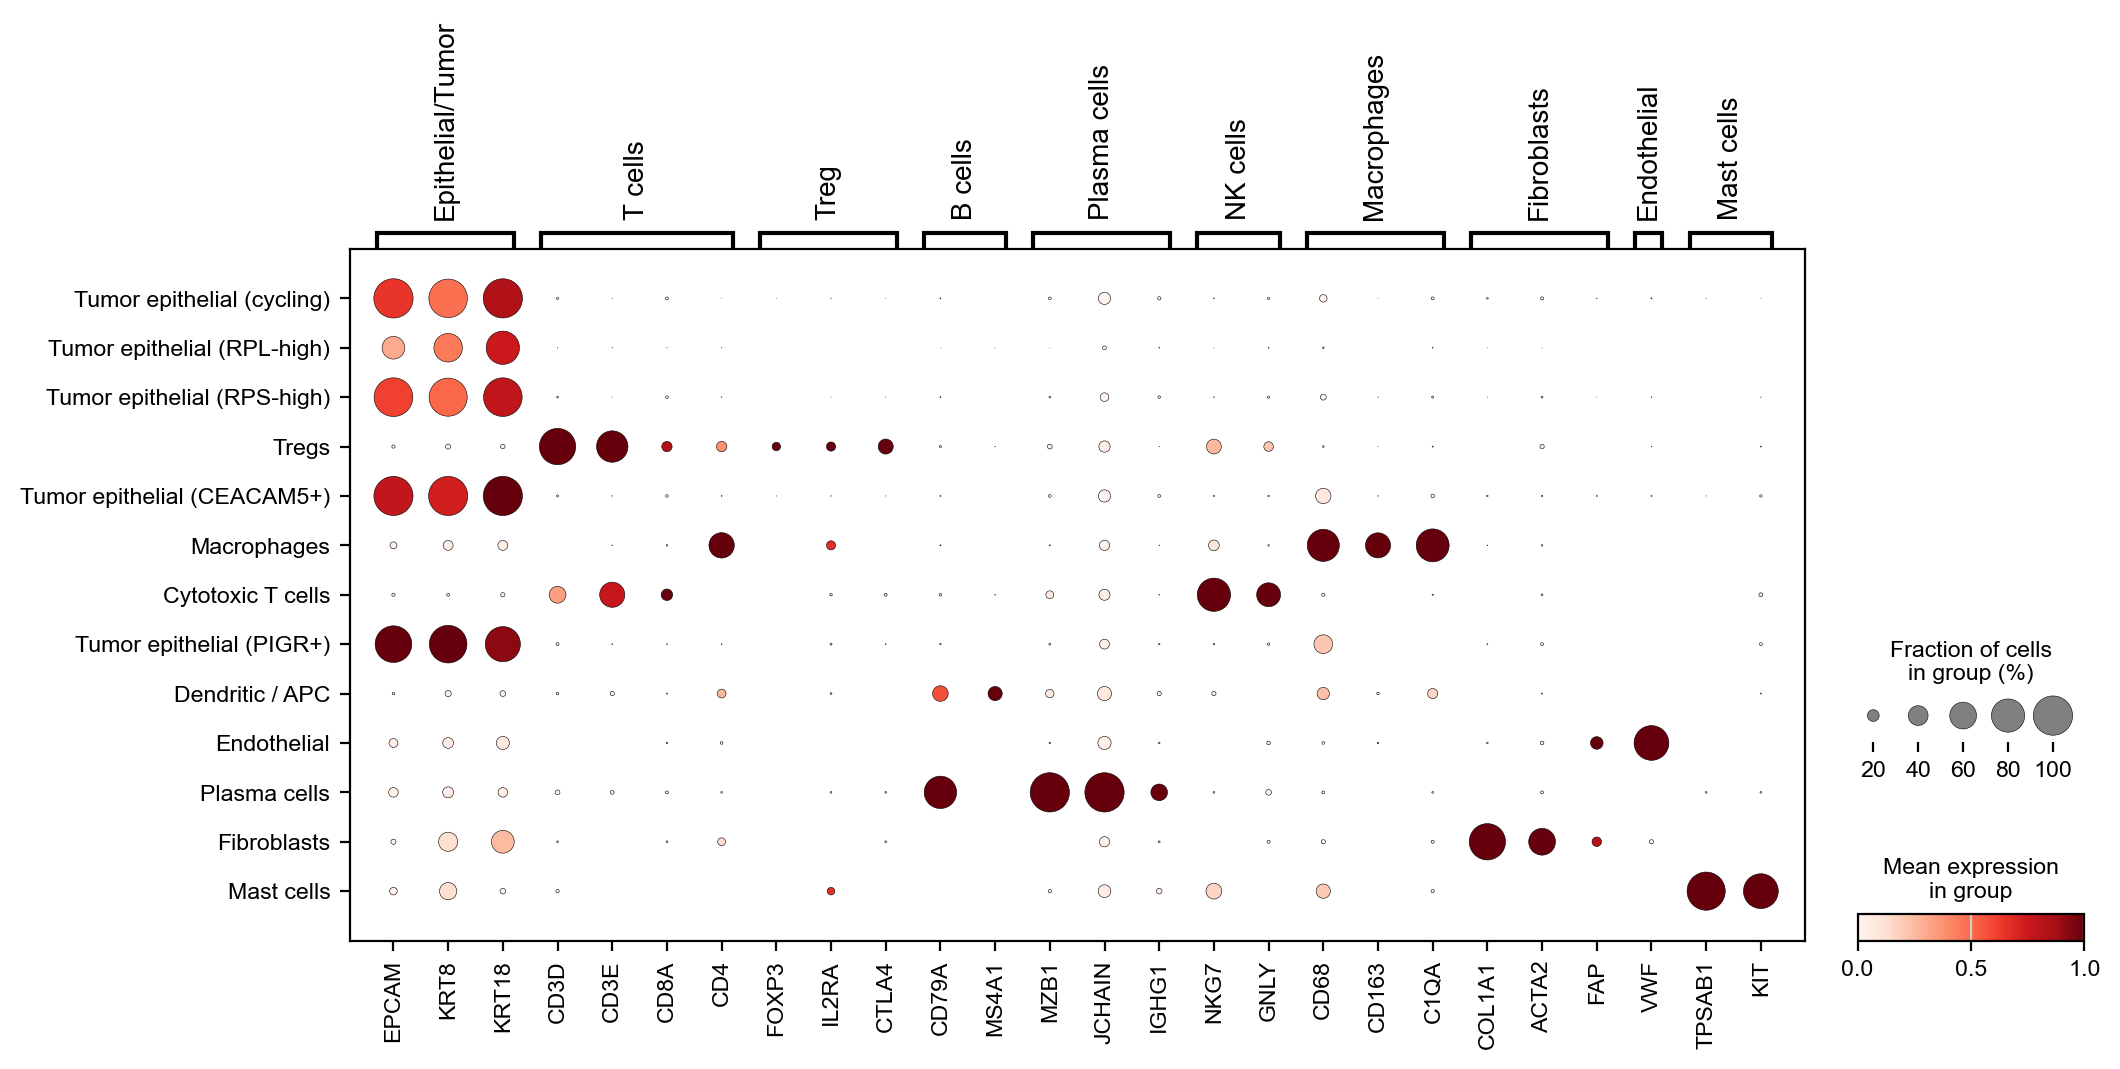

In [53]:
# 3. Marker dot plot grouped by final annotation.
sc.pl.dotplot(
    adata,
    var_names=present,
    groupby="cell_type_manual",
    standard_scale="var",
    save="_FINAL_marker_dotplot.png",
)

The dot plot serves as the rigorous validation of the annotation: each cell type lights up uniquely on its lineage markers (epithelial on EPCAM/KRT8, Tregs on FOXP3/IL2RA, macrophages on CD68/CD163/C1QA, etc.), with no off-target marker leakage.


In [54]:
# Save the final deliverable.
final_path = DATA_PROCESSED / "09_crc_donor_final_annotated.h5ad"
adata.write_h5ad(final_path)

print(f"Final deliverable:")
print(f"  Path:  {final_path}")
print(f"  Shape: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"  Size:  {final_path.stat().st_size / 1e6:.1f} MB")
print(f"  obs columns: {len(adata.obs.columns)} (clinical + QC + clusters + annotations + scores)")

Final deliverable:
  Path:  /Users/arunak/Claude/Geneformer-finetune/data/processed/09_crc_donor_final_annotated.h5ad
  Shape: 4,890 cells × 38,361 genes
  Size:  270.1 MB
  obs columns: 69 (clinical + QC + clusters + annotations + scores)


---

## Discussion and conclusions

### What this analysis demonstrates

Starting from a publicly-available colorectal cancer scRNA-seq atlas, we executed the complete scverse/Scanpy pipeline on a single patient: data acquisition with controlled raw-counts handling; cancer-appropriate quality control; doublet detection; normalization and feature selection; graph-based dimensionality reduction and clustering; dual-method cell-type annotation; tumor identification via cell-cycle scoring; and immune subtype refinement.

### Clinical interpretation for patient C103

The integration of clinical metadata (MMRp, left-sided, low grade) with computational findings (substantial proliferating tumor compartment, Treg-rich and M2-dominant immune microenvironment, naive-dominant T-cell pool, small and exhausted cytotoxic compartment) produces a coherent **cold-tumor profile**. This patient would most likely benefit from standard surgical resection plus adjuvant chemotherapy rather than checkpoint immunotherapy — a profile shared by the majority of CRC patients (~85% are MMRp).

### Limitations

- **Single patient.** Compositional claims are illustrative; population-level conclusions require multi-patient cohorts.
- **Tumor-vs-normal in quiescent epithelial clusters.** Cell-cycle scoring identifies actively-dividing tumor but cannot definitively classify quiescent epithelial cells. Production analysis would use inferCNV/copyKAT for copy-number-based tumor identification.
- **Single-modality.** scRNA-seq captures transcript abundance only. Cell-surface protein expression (CITE-seq), chromatin accessibility (scATAC-seq), and spatial location (Visium/Xenium) are complementary readouts not addressed here.
- **No batch effects or integration concerns** since this is a single-sample analysis; multi-sample work would require Harmony, scVI, or equivalent batch-correction methods.

### Future work — this project's roadmap

- **Phase B: Spatial transcriptomics.** Apply Visium or Xenium to a CRC tumor section. Map the cell types identified here onto physical locations. Test for the "multicellular immune hubs" Pelka et al. reported.
- **Phase C: Foundation-model fine-tuning.** Use this annotated atlas to fine-tune **Geneformer**, a transformer pre-trained on 30M single cells, for tumor-specific downstream prediction tasks.

### Deliverable

`data/processed/09_crc_donor_final_annotated.h5ad` is the complete annotated cell atlas for patient C103. The 67 columns in `adata.obs` carry every analytical trace — patient clinical context, QC metrics, doublet status, three Leiden clusterings, manual and machine-learning annotations, cell-cycle phase and scores, and immune subtype activity scores. Ready for downstream integration and modeling.
